# Exercise 2b: Numerical Simulation of the Advection Equation

## Learning Objectives

By completing this exercise, you will:
- Solve the advection equation numerically using finite differences
- Implement forward-in-time, forward-in-space (FTFS) scheme
- Apply periodic boundary conditions
- Compare numerical results with analytical solutions
- Understand the CFL condition for numerical stability

---

## Introduction

In this exercise, you will conduct your first numerical simulation of time evolution. We will solve the **advection equation**:

$$\frac{\partial u}{\partial t} + a \frac{\partial u}{\partial x} = 0  \tag{1}$$

where $a$ is a **constant**. In subsequent exercises, more general cases will be considered with $a$ no longer constant.

---

## Part 1: The Mathematical Problem ($a = \text{const}$)

### Problem Setup

Solve equation (1) numerically for $x \in [x_0, x_f]$ with:
- $x_0 = -2.6$, $x_f = 2.6$
- **Periodic boundary conditions**
- Initial condition:

$$u(x,t=t_0) = \cos^2 \left(\frac{6 \pi x}{5} \right) / \cosh(5x^2) \tag{2}$$

Start by representing this function in the given interval.

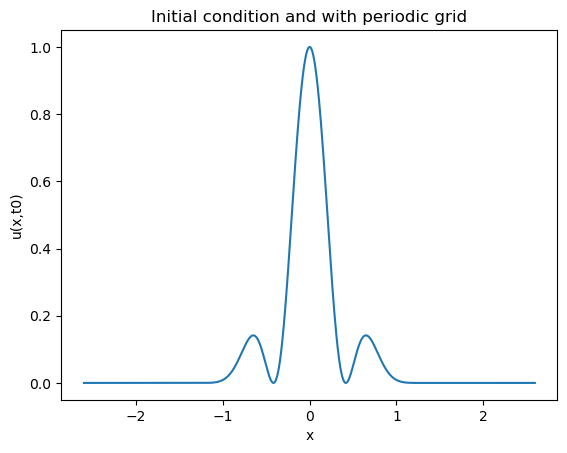

In [9]:
import numpy as np 
import matplotlib.pyplot as plt
import torch   

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)
#Exercises 2b

#Exercises 2b part 1
#consider the intial value

# interval
x0, xf = -2.6, 2.6
L = xf - x0

# grid (periodic: exclude xf)
N = 1000
dx = L / N
x = x0 + dx * torch.arange(N, dtype=dtype, device=device)

# initial condition
def u0(x):
    return torch.cos(6 * torch.pi * x / 5) ** 2 / torch.cosh(5 * x**2)

u_init = u0(x)

# plot
plt.figure()
plt.plot(x.detach().cpu().numpy(), u_init.detach().cpu().numpy())
plt.xlabel("x")
plt.ylabel("u(x,t0)")
plt.title("Initial condition and with periodic grid")
plt.show()

---

## Part 2: Spatial Derivative

### Discretization

Discretize the initial condition by subdividing the spatial domain into `nint = 64` equal intervals. The function is sampled with `nump = 65` points: $(u_0, u_1, u_2, \ldots, u_{nump-1})$ at equidistant locations $(x_0, x_1, x_2, \ldots, x_{nump-1})$.

Calculate the spatial derivative using **non-centered (forward) finite differences**:

$$\left(\frac{\partial u}{\partial x}\right)_{x=x_i} \rightarrow \frac{u_{i+1}-u_{i}}{\Delta x}  \tag{3}$$

> **Question:** Based on your experience from Exercise 1, what order of approximation can we expect when using **non-centered** finite differences?

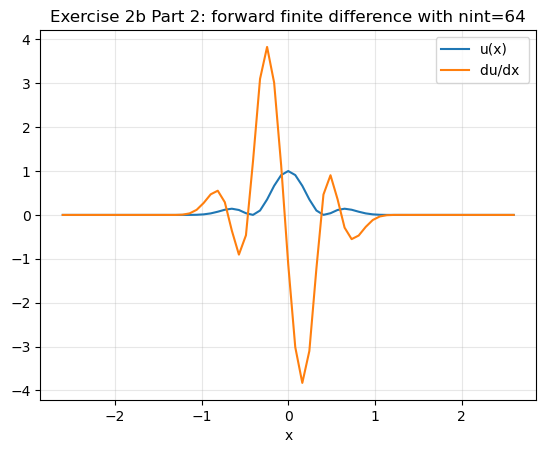

In [10]:
#Exercises part 2

# forward FD

# We consider the same result from privious problems
#Consider the nits
nits = 64

#The mesh points
nump = nits + 1 

# The steps 
dx = (xf - x0) / nits

# Construct the Mesh point
x = x0 + dx * torch.arange(nump, dtype=dtype, device=device)
u = u0(x)

#Forward du/dx
dudx = torch.zeros_like(u)

for i in range(nump - 1):                 # i = 0..63
    dudx[i] = (u[i + 1] - u[i]) / dx

# periodic forward difference for the last point
dudx[nump - 1] = (u[0] - u[nump - 1]) / dx

# Plot
plt.figure()
plt.plot(x.detach().cpu().numpy(), u.detach().cpu().numpy(), label="u(x)")
plt.plot(x.detach().cpu().numpy(), dudx.detach().cpu().numpy(), label="du/dx ")
plt.xlabel("x")
plt.legend()
plt.title("Exercise 2b Part 2: forward finite difference with nint=64")
plt.grid(True, alpha=0.3)
plt.show()


---

## Part 3: Time Advance

### Time Discretization

To calculate the function at times later than $t = t_0$ (e.g., at $t_0 + \Delta t$), we discretize the time axis:

$$\left(\frac{\partial u}{\partial t}\right)_{\underset{t=t_0}{x=x_i}} \rightarrow \frac{u_i(t_0 + \Delta t)-u_i(t_0)}{\Delta t}\tag{4}$$

### The Update Formula

Using the differential equation (1) and expression (3), we obtain the **FTFS scheme**:

$$u_i(t_0+\Delta t) = u_i(t_0) - a \frac{u_{i+1}(t_0) - u_{i}(t_0)}{\Delta x}\Delta t  \tag{5}$$

### Task 3.1: Implement the Time Step

Using (5), calculate $u_i$ at time $t_0 + \Delta t$ at all points **excluding** the rightmost point ($x_{nump-1}$).

**Parameters:**
- $\Delta t = 0.98 \, \Delta x / |a|$ (CFL condition)
- $a = -1$

**Implementation:** Fill in the functions `step_adv_burgers` and `cfl_adv_burger` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_2.py).

---

## Part 4: Boundary Conditions

### Task 4.1: Apply Periodic Boundaries

To calculate the function at the rightmost point, apply **periodicity**:
$$u_{nump-1}(t_0 + \Delta t) = u_0(t_0 + \Delta t)$$

> **Tip:** Consider cutting ill-calculated (or missing) grid points and using `numpy.pad` with `mode='wrap'` to add periodic boundary conditions.

In [11]:
# Task 3.1

#Define the function
def cfl_adv_burger(dx, a, cfl=0.98):
    dt = cfl * dx / abs(a)
    return dt


def step_adv_burgers(u, dx, a=-1.0, cfl=0.98):
    # Apply the FTFS
    # u_i^{n+1} = u_i^n - a * (u_{i+1}^n - u_i^n)/dx * dt

    dt = cfl_adv_burger(dx, a=a, cfl=cfl)

    unew = u.clone()
    unew[:-1] = u[:-1] - a * (u[1:] - u[:-1]) * (dt / dx)

    # Task 4.1
    #The part 4
    # The boundary conditions 
    #We consider the boundary conditions, this means that 
    # we have periodic boundary conditions.
    # Thus the right neighbor of the last point is the first point.
    # Task 4: periodic boundary
    unew[-1] = u[-1] - a * (u[0] - u[-1]) * (dt / dx)

    return unew

---

## Part 5: Time Evolution

### The General Time-Stepping Formula

Having calculated $u_i$ at time $t_0 + \Delta t$, we can continue stepping forward. In general, if $u^n_i$ denotes the value at position $x_i$ and time $n\Delta t$:

$$u_i^{n+1} = u_i^n - a \frac{u_{i+1}^n - u_i^n}{\Delta x}\Delta t  \tag{6}$$

Apply periodic boundary conditions (as in Part 4) at each timestep.

### Task 5.1: Implement the Evolution Loop

Fill in the function `evolv_adv_burgers` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_2.py).

### Task 5.2: Visualize the Evolution

Run many time steps to understand the mathematical nature of the solution.

> **Tip:** Use `matplotlib.animation` to visualize the time evolution.

In [12]:
# The Part 5: Time Evolution
# We want to evolve u(x,t) in time using FTFS scheme.
# PDE: u_t + a u_x = 0   (a is constant)
# Scheme: u_i^{n+1} = u_i^n - a*(u_{i+1}^n - u_i^n) * dt/dx
# Periodic BC: the "right neighbor" of last point is the first point.
# We consider the function.

def evolv_adv_burgers(u, dx, nsteps, a=-1.0, cfl=0.98):
    dt = cfl_adv_burger(dx, a=a, cfl=cfl)   # Compute the distance of steps
    u_now = u.clone()

    for _ in range(nsteps):
        u_new = u_now.clone()

        # i = 0..N-2
        u_new[:-1] = u_now[:-1] - a * (u_now[1:] - u_now[:-1]) * (dt / dx)

        # i = N-1: BC
        u_new[-1] = u_now[-1] - a * (u_now[0] - u_now[-1]) * (dt / dx)

        u_now = u_new

    return u_now

---

## Part 6: Comparison with Exact Solution

### Task 6.1: Compare with Analytical Solution

From theory, we know the exact solution of eq. (1) for initial condition (2). 

**Steps:**
1. Plot the exact solution on top of the numerical one using a dashed line
2. Explain the mathematical behavior of the solution

> **Important:** The initial condition is eq. (2) in $[x_0, x_f]$ **with periodic boundary conditions**. This means the initial condition is an infinite repetition of function (2) placed side by side.

> **Hint:** Points starting within $(x_0, x_f)$ and moving with speed $a$ will exit the domain. You could use (not only solution):
> - The `%` (mod) operator to bring them back respecting periodicity, or
> - `numpy.pad` with ghost points at both ends of the domain

Part 6:
T_used = 0.9988159999999999
L1=1.1282e-03, L2=1.0356e-03, Linf=1.4745e-03


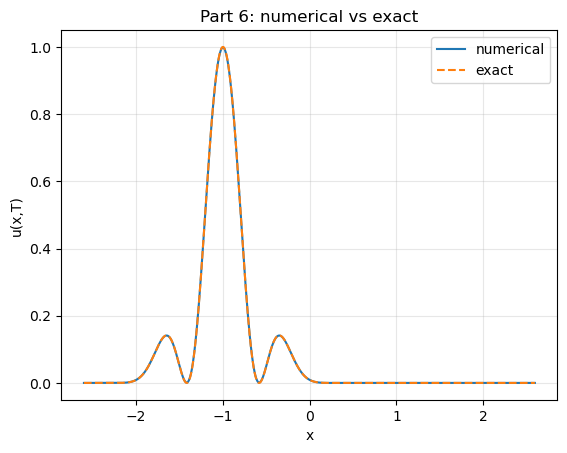

In [13]:
# The Part 6: Comparison with Exact Solution

#Define the function
def u_exact_periodic(x, T, a, x0, xf):
    L = xf - x0
    x_shift = x - a * T
    x_wrap = x0 + torch.remainder(x_shift - x0, L)  # wrap to [x0,xf)
    return u0(x_wrap)

#Define the norm, with the subtraction
def error_norms(err, dx):
    eL1 = dx * torch.sum(torch.abs(err))
    eL2 = torch.sqrt(dx * torch.sum(err**2))
    eLinf = torch.max(torch.abs(err))
    return float(eL1), float(eL2), float(eLinf)

# In this problem we will compare the numerical and exact solution.

# Parameter
a = -1.0
cfl = 0.98
T = 1.0

# Use periodic grid [x0, xf)
N = 1000
L = xf - x0
dx = L / N
x = x0 + dx * torch.arange(N, dtype=dtype, device=device) # grid points , periodic domain

u_init = u0(x)

# choose nsteps so that T_used matches numerical time
dt = cfl_adv_burger(dx, a=a, cfl=cfl)
nsteps = int(round(T / dt))
T_used = nsteps * dt

u_num = evolv_adv_burgers(u_init, dx, nsteps, a=a, cfl=cfl)
u_ex  = u_exact_periodic(x, T_used, a=a, x0=x0, xf=xf)

err = u_num - u_ex
eL1, eL2, eLinf = error_norms(err, dx)
print("Part 6:")
print("T_used =", float(T_used))
print(f"L1={eL1:.4e}, L2={eL2:.4e}, Linf={eLinf:.4e}")

plt.figure()
plt.plot(x.detach().cpu().numpy(), u_num.detach().cpu().numpy(), label="numerical")
plt.plot(x.detach().cpu().numpy(), u_ex.detach().cpu().numpy(), "--", label="exact")
plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Part 6: numerical vs exact")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Task 6.2: Set Up CI/CD Testing

Add a CI/CD pipeline to run this test and validate each push commit. This ensures that submitted changes don't break existing code.

**Implementation:** Fill in `./github/workflows/main.yml`

In [14]:
# 6.2

# So here we add simple tests in the same file to check the implementation.
# The CI/CD workflow is still written separately in .github/workflows/test.yml

def test_cfl_adv_burger():
    dx_test = (xf - x0) / 64
    dt_test = cfl_adv_burger(dx_test, a=-1.0, cfl=0.98)
    dt_expected = 0.98 * dx_test / abs(-1.0)
    assert abs(float(dt_test) - float(dt_expected)) < 1e-14


def test_step_adv_burgers_shape():
    N_test = 100
    dx_test = (xf - x0) / N_test
    x_test = x0 + dx_test * torch.arange(N_test, dtype=dtype, device=device)
    u_test = u0(x_test)

    u_new = step_adv_burgers(u_test, dx_test, a=-1.0, cfl=0.98)

    assert u_new.shape == u_test.shape


def test_periodic_boundary_last_point():
    N_test = 100
    dx_test = (xf - x0) / N_test
    x_test = x0 + dx_test * torch.arange(N_test, dtype=dtype, device=device)
    u_test = u0(x_test)

    dt_test = cfl_adv_burger(dx_test, a=-1.0, cfl=0.98)
    u_new = step_adv_burgers(u_test, dx_test, a=-1.0, cfl=0.98)

    u_last_expected = u_test[-1] - (-1.0) * (u_test[0] - u_test[-1]) * (dt_test / dx_test)

    assert torch.abs(u_new[-1] - u_last_expected) < 1e-12


def test_evolution_runs():
    N_test = 100
    dx_test = (xf - x0) / N_test
    x_test = x0 + dx_test * torch.arange(N_test, dtype=dtype, device=device)
    u_test = u0(x_test)

    u_num_test = evolv_adv_burgers(u_test, dx_test, 10, a=-1.0, cfl=0.98)

    assert u_num_test.shape == u_test.shape
    assert torch.all(torch.isfinite(u_num_test))


def test_error_is_reasonable():
    N_test = 200
    dx_test = (xf - x0) / N_test
    x_test = x0 + dx_test * torch.arange(N_test, dtype=dtype, device=device)
    u_test = u0(x_test)

    T_test = 1.0
    dt_test = cfl_adv_burger(dx_test, a=-1.0, cfl=0.98)
    nsteps_test = int(round(T_test / dt_test))
    T_used_test = nsteps_test * dt_test

    u_num_test = evolv_adv_burgers(u_test, dx_test, nsteps_test, a=-1.0, cfl=0.98)
    u_ex_test  = u_exact_periodic(x_test, T_used_test, a=-1.0, x0=x0, xf=xf)

    err_test = u_num_test - u_ex_test
    _, eL2_test, _ = error_norms(err_test, dx_test)

    assert eL2_test < 2e-1


print("Part 6.2:")
print("Run simple tests in this file")

test_cfl_adv_burger()
print("test_cfl_adv_burger passed")

test_step_adv_burgers_shape()
print("test_step_adv_burgers_shape passed")

test_periodic_boundary_last_point()
print("test_periodic_boundary_last_point passed")

test_evolution_runs()
print("test_evolution_runs passed")

test_error_is_reasonable()
print("test_error_is_reasonable passed")

print("All Part 6.2 tests passed")

Part 6.2:
Run simple tests in this file
test_cfl_adv_burger passed
test_step_adv_burgers_shape passed
test_periodic_boundary_last_point passed
test_evolution_runs passed
test_error_is_reasonable passed
All Part 6.2 tests passed


---

## Part 7: Resolution Study

### Task 7.1: Convergence with Resolution

Repeat the calculation increasing the number of spatial intervals by factors of 2. Verify that the numerical solution approaches the analytical solution.

> **Important:** Compare at the **same values of $x$ and $t$** for all resolutions. Choose a fixed time when the traveling function has crossed the domain several times.

---

## Hints

<details>
<summary><b>Hint 1: The CFL condition</b></summary>

The Courant-Friedrichs-Lewy (CFL) condition ensures stability:
$$\text{CFL} = \frac{|a| \Delta t}{\Delta x} \leq 1$$

Using $\Delta t = 0.98 \, \Delta x / |a|$ gives CFL = 0.98, safely below 1.
</details>

<details>
<summary><b>Hint 2: Periodic boundary with numpy.pad</b></summary>

```python
u_padded = np.pad(u[:-1], (0, 1), mode='wrap')
```
This wraps the first point to the last position.
</details>

<details>
<summary><b>Hint 3: Animation setup</b></summary>

```python
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
line, = ax.plot(x, u)

def update(frame):
    # Advance solution
    line.set_ydata(u_new)
    return line,

ani = FuncAnimation(fig, update, frames=nsteps)
```
</details>

N=   50, dx=1.0400e-01,  L2=1.8377e-01
N=  100, dx=5.2000e-02,  L2=1.1560e-01
N=  200, dx=2.6000e-02,  L2=6.6473e-02
N=  400, dx=1.3000e-02,  L2=3.5862e-02
N=  800, dx=6.5000e-03,  L2=1.8681e-02
N= 1600, dx=3.2500e-03,  L2=9.5378e-03


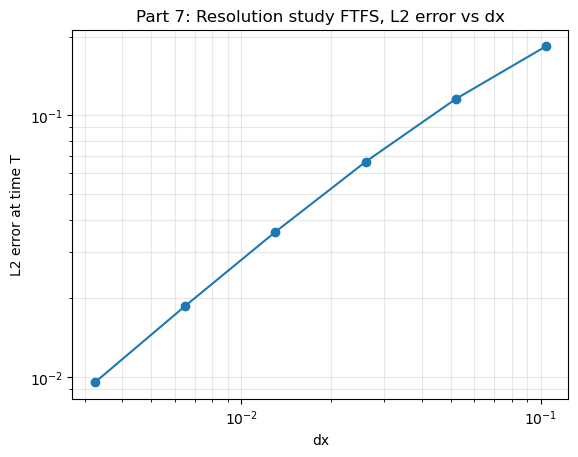

Observed orders (L2): [0.66879084 0.79828933 0.89034287 0.94087412 0.96983486]
Mean order: 0.8536264024605223


In [15]:
# The   Part 7: Resolution Study

#We consider a finer nits

# Parameter
T = 15.0
a = -1.0
cfl = 0.98

# The finer nits
nits_new_list = [50, 100, 200, 400, 800, 1600]

dx_list = []
eL2_list = []

for N in nits_new_list:
    L = xf - x0
    dx = L / N
    x = x0 + dx * torch.arange(N, dtype=dtype, device=device)
    u_init = u0(x)

    dt = cfl_adv_burger(dx, a=a, cfl=cfl)
    nsteps = int(round(T / dt))
    T_used = nsteps * dt

    u_num = evolv_adv_burgers(u_init, dx, nsteps, a=a, cfl=cfl)
    u_ex  = u_exact_periodic(x, T_used, a=a, x0=x0, xf=xf)

    err = u_num - u_ex
    _, eL2, _ = error_norms(err, dx)

    dx_list.append(float(dx))
    eL2_list.append(float(eL2))

    print(f"N={N:5d}, dx={dx:.4e},  L2={eL2:.4e}")

#Plot 
plt.figure()
plt.loglog(dx_list, eL2_list, marker="o")
plt.xlabel("dx")
plt.ylabel("L2 error at time T")
plt.title("Part 7: Resolution study FTFS, L2 error vs dx")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# observed order
dx_np = np.array(dx_list)
e_np  = np.array(eL2_list)
p_list = np.log(e_np[:-1] / e_np[1:]) / np.log(dx_np[:-1] / dx_np[1:])

print("Observed orders (L2):", p_list)
print("Mean order:", p_list.mean())


In [16]:
#Conclustion


# Exercises 2b part 1
# The intial profile has one sharp main peak at x =0 and small side peaks.
# And it becomes almost zero near x = +-2.6


# The second plot
# The blue curve is the function u(x)
# The orange curve is the forward difference approximation of du/dx.
# It is large around the steep parts of u(x) and near zero where u(x) is flat.


# Part 6 
# The numerical and exact solution nearly coincide at T=1
# And the error norms are around 10^-3. So the method is accurate for this test.


# Part 7
# Resolution study.
# L2 error vs \Delta x on the log log scale.
# The slope is close to 1, confirming first order convergence.